Analyse KNN via Distance de CHEBYSHEV
---------------------------------------------
K     | Note Prédite | Résultat
---------------------------------------------
1     | 7.00         | Échec
2     | 9.00         | Échec
3     | 9.00         | Échec
4     | 8.75         | Échec
5     | 9.00         | Échec
6     | 9.17         | Échec
7     | 10.36        | Réussite
8     | 10.44        | Réussite
9     | 10.28        | Réussite
10    | 10.45        | Réussite


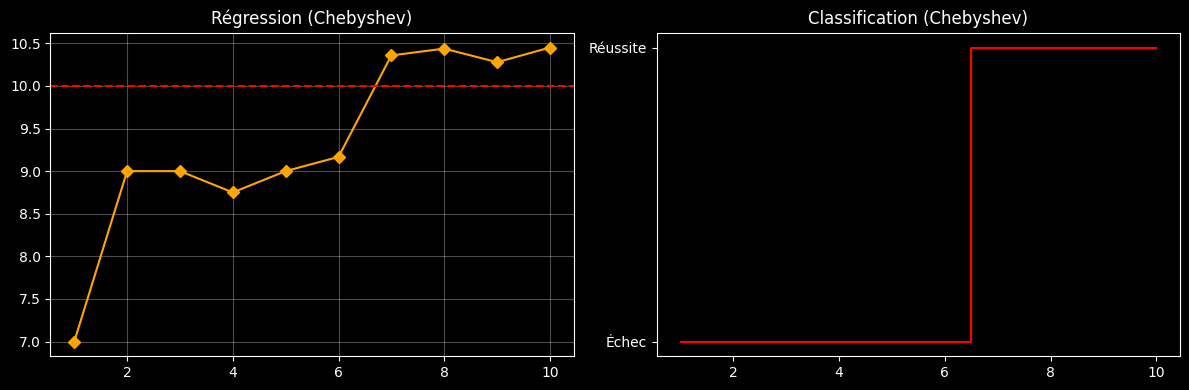

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. DATASET ENRICHI
# =============================================================================
X = np.array([
    [2,5,8,20,0,6], [4,6,6,40,2,5], [6,7,5,60,3,4], [8,7,4,80,4,3], [10,8,3,90,5,2],
    [3,4,9,30,0,7], [7,6,5,70,3,4], [5,5,6,50,2,5], [9,8,4,85,4,3], [1,3,9,15,1,8],
    [6,6,5,65,3,4], [7,7,4,75,3,3], [8,8,3,88,4,2], [2,4,8,25,1,6], [3,5,7,35,2,6],
    [4,7,6,45,2,5], [5,6,6,55,3,4], [6,8,5,68,3,3], [7,5,5,72,4,3], [9,7,4,82,4,2],
    [10,9,3,95,5,1], [2,3,9,10,1,9], [3,4,8,28,2,7], [6,5,6,60,3,4], [7,6,5,70,3,3],
    [8,7,4,78,4,2], [9,8,3,88,5,2], [1,2,9,12,0,9], [2,6,7,22,1,7], [3,7,6,32,1,6],
    [4,8,5,42,2,5], [5,9,4,52,2,4], [6,3,8,62,3,5], [7,4,7,72,3,4], [8,5,6,82,4,3],
    [9,6,5,92,5,2], [10,7,4,98,5,1], [2,5,7,18,0,8], [3,6,6,28,1,7], [4,7,5,38,2,6],
    [5,8,4,48,2,5], [6,9,3,58,3,4], [7,3,9,68,3,6], [8,4,8,78,4,5], [9,5,7,88,4,4],
    [10,6,6,96,5,3], [1,7,8,14,1,8]
])

notes = np.array([
    10, 13, 15, 17, 18.5, 11, 16, 12, 17, 9, 14, 15, 18, 10, 11,
    13, 14, 15, 16, 17, 19, 8, 9, 14, 15, 16, 17, 7, 8, 9.5, 10.5,
    11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18, 19, 20, 6, 7.5,
    8.5, 9, 10, 11, 12, 13
])

# =============================================================================
# 2. PRÉ-TRAITEMENT (Normalisation Statistique)
# Importance : Indispensable pour Chebyshev car sinon la variable avec la plus
# grande unité brute écrasera systématiquement toutes les autres.
# =============================================================================
X_mean, X_std = np.mean(X, axis=0), np.std(X, axis=0)
X_norm = (X - X_mean) / X_std

# =============================================================================
# 3. CALCULATEUR DE DISTANCES MULTI-MÉTRIQUES
# =============================================================================
def calculer_distance(x1, x2, methode="chebyshev"):
    if methode == "chebyshev":
        # Logique : max(|x_i - y_i|)
        return np.max(np.abs(x1 - x2))
    elif methode == "manhattan":
        return np.sum(np.abs(x1 - x2))
    else: # Euclidienne par défaut
        return np.sqrt(np.sum((x1 - x2)**2))

# =============================================================================
# 4. ALGORITHME KNN
# =============================================================================
def moteur_knn(X_train, y_train, x_test, K, mode="chebyshev"):
    distances = []
    for i in range(len(X_train)):
        d = calculer_distance(x_test, X_train[i], methode=mode)
        distances.append((d, y_train[i]))

    # Tri des plus proches voisins
    distances.sort(key=lambda x: x[0])
    k_voisins = distances[:K]

    # Calcul de la note moyenne
    return np.mean([v[1] for v in k_voisins])

# =============================================================================
# 5. TEST ET AFFICHAGE (Profil Échec)
# =============================================================================
etudiant_test = np.array([[2, 3, 9, 15, 0, 8]]) # Profil faible
x_test_norm = ((etudiant_test - X_mean) / X_std).flatten()

SEUIL = 10
pred_notes = []
pred_classes = []

print(f"Analyse KNN via Distance de CHEBYSHEV")
print("-" * 45)
print(f"{'K':<5} | {'Note Prédite':<12} | {'Résultat'}")
print("-" * 45)

for K in range(1, 11):
    note_finale = moteur_knn(X_norm, notes, x_test_norm, K, mode="chebyshev")
    classe = 1 if note_finale >= SEUIL else 0
    statut = "Réussite" if classe == 1 else "Échec"

    pred_notes.append(note_finale)
    pred_classes.append(classe)
    print(f"{K:<5} | {note_finale:<12.2f} | {statut}")

# =============================================================================
# 6. VISUALISATION
# =============================================================================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), pred_notes, 'D-', color='orange', label='Chebyshev Pred')
plt.axhline(y=SEUIL, color='red', linestyle='--')
plt.title("Régression (Chebyshev)")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.step(range(1, 11), pred_classes, where='mid', color='red')
plt.yticks([0, 1], ["Échec", "Réussite"])
plt.title("Classification (Chebyshev)")
plt.tight_layout()
plt.show()